# Projet OC P7 — Modélisation

Trois approches : modèle simple (TF-IDF), modèle avancé (CNN-LSTM + embeddings), BERT (DistilBERT).
Split train/validation/test : 60/20/20. Tracking MLflow.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import mlflow
from pathlib import Path

mlflow.set_tracking_uri(f"file://{Path('../mlruns').resolve()}")
mlflow.set_experiment('air-paradis-sentiment')

/Users/laureendademeule/Documents/Projets/P7/.venv/lib/python3.13/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


/Users/laureendademeule/Documents/Projets/P7/.venv/lib/python3.13/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///Users/laureendademeule/Documents/Projets/P7/air-paradis-sentiment/mlruns/205854119803115726', creation_time=1779465091245, experiment_id='205854119803115726', last_update_time=1779465091245, lifecycle_stage='active', name='air-paradis-sentiment', tags={}, trace_location=None, workspace='default'>

In [2]:
df = pd.read_csv('../data/processed/cleaned_dataset_sentiment.csv')

# Échantillon stratifié de 50 000 tweets (même taille que le pipeline de production)
df = (
    df.groupby('target', group_keys=False)
    .apply(lambda x: x.sample(25000, random_state=42))
    .reset_index(drop=True)
)
print(f"Échantillon : {len(df)} tweets — {df['target'].value_counts().to_dict()}")
df.head()

Échantillon : 50000 tweets — {0: 25000, 1: 25000}


/var/folders/q1/yy2wcr4j61g8k3kwf0r74nnh0000gn/T/ipykernel_50794/3587093674.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(25000, random_state=42))


,target,ids,date,flag,user,text,sentiment,word_count,cleaned_text
0,0,1974671194,Sat May 30 13:36:31 PDT 2009,NO_QUERY,simba98,@xnausikaax oh no! where did u order from? tha...,Negatif,10,oh no where did u order from thats horrible
1,0,1997882236,Mon Jun 01 17:37:11 PDT 2009,NO_QUERY,Seve76,A great hard training weekend is over. a coup...,Negatif,25,a great hard training weekend is over a coupl...
2,0,2177756662,Mon Jun 15 06:39:05 PDT 2009,NO_QUERY,x__claireyy__x,"Right, off to work Only 5 hours to go until I...",Negatif,13,right off to work only 5 hours to go until im...
3,0,2216838047,Wed Jun 17 20:02:12 PDT 2009,NO_QUERY,Balasi,I am craving for japanese food,Negatif,6,i am craving for japanese food
4,0,1880666283,Fri May 22 02:03:31 PDT 2009,NO_QUERY,djrickdawson,Jean Michel Jarre concert tomorrow gotta work...,Negatif,10,jean michel jarre concert tomorrow gotta work...


## A. Modèles simples — TF-IDF

In [3]:
X = df['cleaned_text']
y = df['target']

vectorizer = TfidfVectorizer(max_features=5000)
X_vec = vectorizer.fit_transform(X)

X_temp, X_test, y_temp, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print('Train:', y_train.value_counts().to_dict())
print('Val:', y_val.value_counts().to_dict())
print('Test:', y_test.value_counts().to_dict())

Train: {1: 15000, 0: 15000}
Val: {1: 5000, 0: 5000}
Test: {0: 5000, 1: 5000}


### Régression logistique

2026/07/19 03:20:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/07/19 03:20:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Validation accuracy: 0.7679 | f1: 0.7690
Test accuracy: 0.7644 | f1: 0.7654
              precision    recall  f1-score   support

     Négatif       0.77      0.76      0.76      5000
     Positif       0.76      0.77      0.77      5000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000



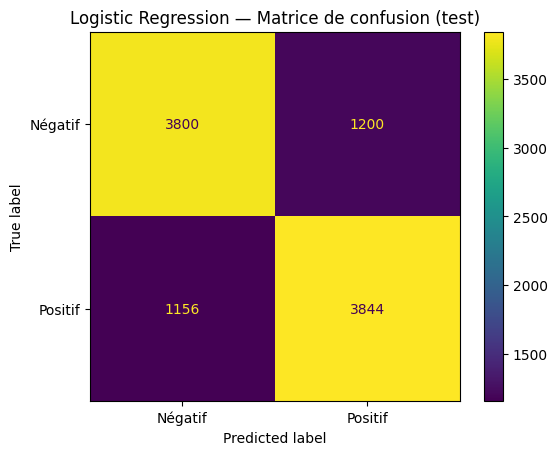

In [4]:
with mlflow.start_run(run_name='tfidf_logistic'):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    y_pred = model.predict(X_test)
    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    test_f1 = f1_score(y_test, y_pred)
    print(f'Validation accuracy: {val_acc:.4f} | f1: {val_f1:.4f}')
    print(f'Test accuracy: {test_acc:.4f} | f1: {test_f1:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Négatif', 'Positif']))
    mlflow.log_metric('val_accuracy', val_acc)
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('val_f1', val_f1)
    mlflow.log_metric('test_f1', test_f1)
    mlflow.sklearn.log_model(model, 'model')

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Négatif', 'Positif']).plot()
plt.title('Logistic Regression — Matrice de confusion (test)')
plt.show()

### Random Forest

2026/07/19 03:20:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/07/19 03:20:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Validation accuracy: 0.7024 | f1: 0.7167
Test accuracy: 0.7025 | f1: 0.7173
              precision    recall  f1-score   support

     Négatif       0.73      0.65      0.69      5000
     Positif       0.68      0.75      0.72      5000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



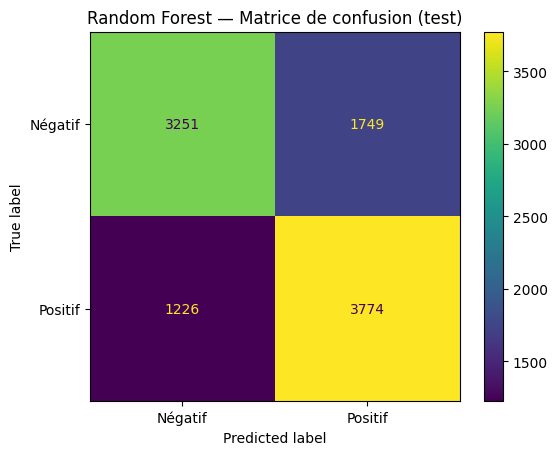

In [5]:
with mlflow.start_run(run_name='tfidf_random_forest'):
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_val_pred = rf.predict(X_val)
    y_pred_rf = rf.predict(X_test)
    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_pred_rf)
    val_f1 = f1_score(y_val, y_val_pred)
    test_f1 = f1_score(y_test, y_pred_rf)
    print(f'Validation accuracy: {val_acc:.4f} | f1: {val_f1:.4f}')
    print(f'Test accuracy: {test_acc:.4f} | f1: {test_f1:.4f}')
    print(classification_report(y_test, y_pred_rf, target_names=['Négatif', 'Positif']))
    mlflow.log_metric('val_accuracy', val_acc)
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('val_f1', val_f1)
    mlflow.log_metric('test_f1', test_f1)
    mlflow.sklearn.log_model(rf, 'model')

cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm, display_labels=['Négatif', 'Positif']).plot()
plt.title('Random Forest — Matrice de confusion (test)')
plt.show()

## B. Modèles avancés — CNN-LSTM + embeddings + BERT

Pipeline complet via `src/training/pipeline.py` (Word2Vec, GloVe, DistilBERT), tracké dans MLflow.
Le pipeline entraîne 5 modèles sur 50 000 tweets (~4h avec DistilBERT sur CPU) ; si `model_comparison.json` existe déjà, on charge les résultats plutôt que de tout réentraîner.

In [6]:
import json
from pathlib import Path

results_path = Path('../models/production/model_comparison.json')

if results_path.exists():
    # Pipeline déjà exécuté (5 modèles, ~4h avec DistilBERT sur CPU) : on charge les résultats
    print('Pipeline déjà exécuté — chargement des résultats existants.')
    results = json.loads(results_path.read_text())
else:
    from training.pipeline import run_pipeline
    results = run_pipeline(sample_size=50000, skip_bert=False)

pd.DataFrame(results)

Pipeline déjà exécuté — chargement des résultats existants.


,model,val_accuracy,val_precision,val_recall,val_f1,test_accuracy,test_precision,test_recall,test_f1,bundle_path,model_dir
0,tfidf_logistic,0.7681,0.765709,0.7726,0.769139,0.76370,0.763331,0.7644,0.763865,NaN,NaN
1,tfidf_random_forest,0.7093,0.687310,0.7680,0.725418,0.70900,0.687680,0.7658,0.724640,NaN,NaN
2,cnn_lstm_word2vec,0.6695,0.691352,0.6124,0.649486,0.67710,0.701204,0.6172,0.656526,/Users/laureendademeule/Documents/Projets/P7/a...,NaN
3,cnn_lstm_glove,0.7063,0.739272,0.6374,0.684567,0.71410,0.745697,0.6498,0.694453,/Users/laureendademeule/Documents/Projets/P7/a...,NaN
4,distilbert_finetuned,0.8025,0.804020,0.8000,0.802005,0.81475,0.815539,0.8135,0.814518,NaN,/Users/laureendademeule/Documents/Projets/P7/a...


## C. Comparaison des modèles

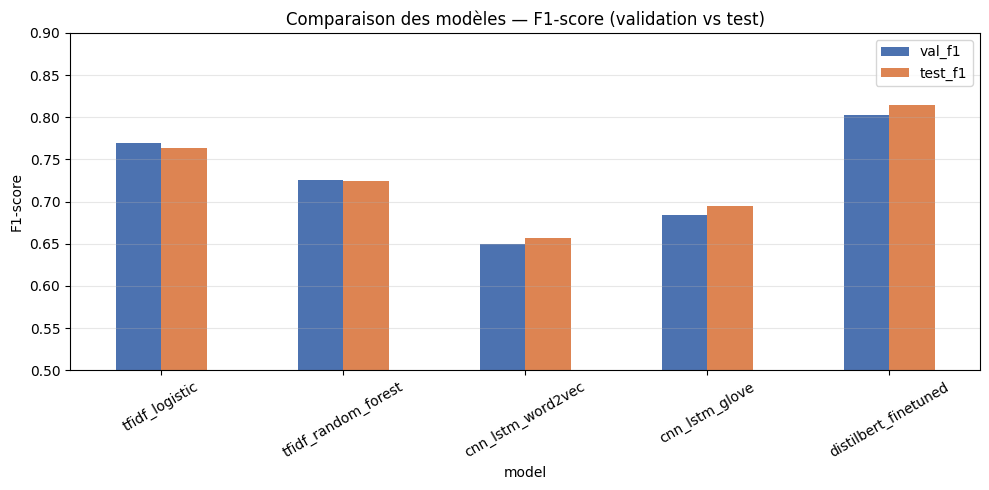

Modèle déployé en production : cnn_lstm_glove


,model,val_accuracy,val_f1,test_accuracy,test_f1
0,tfidf_logistic,0.7681,0.769139,0.76370,0.763865
1,tfidf_random_forest,0.7093,0.725418,0.70900,0.724640
2,cnn_lstm_word2vec,0.6695,0.649486,0.67710,0.656526
3,cnn_lstm_glove,0.7063,0.684567,0.71410,0.694453
4,distilbert_finetuned,0.8025,0.802005,0.81475,0.814518


In [7]:
comparison = pd.DataFrame(results)[['model', 'val_accuracy', 'val_f1', 'test_accuracy', 'test_f1']]

# Graphique comparatif
ax = comparison.set_index('model')[['val_f1', 'test_f1']].plot.bar(figsize=(10, 5), rot=30, color=['#4C72B0', '#DD8452'])
ax.set_title('Comparaison des modèles — F1-score (validation vs test)')
ax.set_ylabel('F1-score')
ax.set_ylim(0.5, 0.9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

production_model = Path('../models/production/production_model.txt').read_text().strip()
print(f'Modèle déployé en production : {production_model}')
comparison